# 02 - AEMO DER Register Data Exploration (Queensland Focus)

**Project:** DER Integration in Queensland

**Author:** Johan Lopez

**Date:** February 15, 2026

**Purpose:** Load and explore AEMO DER Register data with specific focus on Queensland. Understand data structure, identify trends, and lay groundwork for integration analysis.

**Data Source:** AEMO DER Register (https://www.aemo.com.au/energy-systems/electricity/der-register/data-der/data-downloads)

**Reporting Date:** December, 2025

---

## 1. Setup & Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Utilities
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✓ Libraries imported successfully!
Analysis Date: 2026-02-17 14:04


## 2. Define File Paths

Set up paths to data folders relative to project root.

In [2]:
# Project structure
project_root = os.path.dirname(os.getcwd())
data_raw = os.path.join(project_root, 'data', 'raw')
data_processed = os.path.join(project_root, 'data', 'processed')
outputs_figures = os.path.join(project_root, 'outputs', 'figures')

# Data file name 
aemo_file = 'aemo_der_register_raw_12-25_cut.csv'  
aemo_filepath = os.path.join(data_raw, aemo_file)

print(f"Data raw folder: {data_raw}")
print(f"Looking for file: {aemo_filepath}")
print(f"File exists: {os.path.exists(aemo_filepath)}")

Data raw folder: C:\Users\jlope\Documents\Projects\DER-Integration-QLD\data\raw
Looking for file: C:\Users\jlope\Documents\Projects\DER-Integration-QLD\data\raw\aemo_der_register_raw_12-25_cut.csv
File exists: True


In [3]:
# Load the data
try:
    df_raw = pd.read_csv(aemo_filepath)
    print(f"✓ Data loaded successfully!")
    print(f"  Total rows: {len(df_raw):,}")
    print(f"  Total columns: {len(df_raw.columns)}")
except FileNotFoundError:
    print("✗ File not found!")
    print(f"  Looking for: {aemo_filepath}")
    print("\n  Please:")
    print("  1. Download the AEMO DER Register CSV from:")
    print("     https://www.aemo.com.au/energy-systems/electricity/der-register/data-der/data-downloads")
    print(f"  2. Save it to: {data_raw}")
    print("  3. Update the 'aemo_file' variable above with the correct filename")
    raise

✓ Data loaded successfully!
  Total rows: 4,179
  Total columns: 15


## 3. Initial Data Exploration

Let's understand what we're working with.

In [4]:
# Display first few rows
print("First 5 rows of data:")
print("=" * 80)
df_raw.head()

First 5 rows of data:


,state,postcode,nmi_bus_res2,Sum of Num_DER_Sites,Sum of Num_DER_Connections,Sum of Installed_DER_capacity_kVA,Sum of Solar_Connections,Sum of Solar_Devices,Sum of Solar_capacity_kVA,Sum of Battery_Connections,Sum of Battery_Devices,Sum of Battery_capacity_kVA,Sum of Battery_Storage_kVAh,Sum of Num_Other_Connections,Sum of Installed_OtherDER_capacity_kVA
0,ACT,<10 sites,NaN,33,41,32662.74,33,1141,573.29,4,4,27.45,69.81,4,32062.00
1,SA,<10 sites,NaN,853,1384,115550.39,1172,39843,37573.95,202,247,5076.44,5538.28,10,72900.00
2,TAS,<10 sites,NaN,232,236,4511.12,155,8656,2993.32,79,85,396.60,18678.04,2,1121.20
3,QLD,<10 sites,NaN,740,1083,11603.04,1035,24264,10770.67,48,68,832.37,1406.13,0,0.00
4,VIC,<10 sites,NaN,1424,3059,237560.71,2745,46288,25112.92,293,262,8302.78,12538.00,21,204145.00


In [5]:
# Column names and types
print("Column Information:")
print("=" * 80)
print(df_raw.dtypes)
print("\n" + "=" * 80)

Column Information:
state                                         str
postcode                                      str
nmi_bus_res2                                  str
Sum of Num_DER_Sites                        int64
Sum of Num_DER_Connections                  int64
Sum of Installed_DER_capacity_kVA         float64
Sum of Solar_Connections                    int64
Sum of Solar_Devices                        int64
Sum of Solar_capacity_kVA                 float64
Sum of Battery_Connections                  int64
Sum of Battery_Devices                      int64
Sum of Battery_capacity_kVA               float64
Sum of Battery_Storage_kVAh               float64
Sum of Num_Other_Connections                int64
Sum of Installed_OtherDER_capacity_kVA    float64
dtype: object



In [6]:
# Basic statistics
print("Numeric Column Statistics:")
print("=" * 80)
df_raw.describe()

Numeric Column Statistics:


,Sum of Num_DER_Sites,Sum of Num_DER_Connections,Sum of Installed_DER_capacity_kVA,Sum of Solar_Connections,Sum of Solar_Devices,Sum of Solar_capacity_kVA,Sum of Battery_Connections,Sum of Battery_Devices,Sum of Battery_capacity_kVA,Sum of Battery_Storage_kVAh,Sum of Num_Other_Connections,Sum of Installed_OtherDER_capacity_kVA
count,4179.00,4179.00,4179.00,4179.00,4179.00,4179.00,4179.00,4179.00,4179.00,4179.00,4179.00,4179.00
mean,770.99,1004.57,5889.86,940.63,8404.39,5100.94,63.85,69.22,569.73,957.98,0.09,219.19
std,1699.56,2071.42,12203.91,1946.25,17727.04,10237.33,141.69,159.33,1603.98,2170.56,0.56,3806.47
min,10.00,0.00,0.00,0.00,10.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,38.00,46.00,439.81,44.00,653.50,412.37,1.00,1.00,5.00,13.20,0.00,0.00
50%,125.00,173.00,1579.55,166.00,2266.00,1386.17,5.00,6.00,53.00,101.78,0.00,0.00
75%,657.00,940.00,5978.61,888.50,8636.50,5289.96,48.00,51.50,438.42,838.48,0.00,0.00
max,23496.00,24763.00,237560.71,23976.00,270174.00,139698.18,1351.00,1568.00,52016.76,30861.50,21.00,204145.00


In [7]:
# Check for missing values
print("Missing Values Analysis:")
print("=" * 80)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))
print("\n" + "=" * 80)

Missing Values Analysis:
              Missing Count  Missing %
nmi_bus_res2              6       0.14



In [8]:
# Unique states in dataset
print("States/Territories in Dataset:")
print("=" * 80)
if 'state' in df_raw.columns:
    print(df_raw['state'].value_counts())
else:
    print("State column not found - showing all columns:")
    print(df_raw.columns.tolist())

States/Territories in Dataset:
state
VIC    1257
NSW    1143
QLD     873
SA      669
TAS     185
ACT      52
Name: count, dtype: int64


## 5. Filter for Queensland Data

Extract only Queensland postcodes for focused analysis.

In [9]:
# Filter for Queensland
# Note: Adjust column names based on actual data structure
# Queensland postcodes typically start with 4 (4000-4999)

# Method 1: If there's a State column
state_col = 'state'

df_qld = df_raw[df_raw[state_col].str.contains('QLD', case=False, na=False)].copy()
print(f"✓ Filtered by State column: {state_col}")

print(f"\nQueensland Data:")
print(f"  Total QLD rows: {len(df_qld):,}")
print(f"  Percentage of total: {(len(df_qld)/len(df_raw)*100):.1f}%")

✓ Filtered by State column: state

Queensland Data:
  Total QLD rows: 873
  Percentage of total: 20.9%


In [10]:
# Quick look at Queensland data
print("Queensland DER Data Sample:")
print("=" * 80)
df_qld.head(10)

Queensland DER Data Sample:


,state,postcode,nmi_bus_res2,Sum of Num_DER_Sites,Sum of Num_DER_Connections,Sum of Installed_DER_capacity_kVA,Sum of Solar_Connections,Sum of Solar_Devices,Sum of Solar_capacity_kVA,Sum of Battery_Connections,Sum of Battery_Devices,Sum of Battery_capacity_kVA,Sum of Battery_Storage_kVAh,Sum of Num_Other_Connections,Sum of Installed_OtherDER_capacity_kVA
3,QLD,<10 sites,NaN,740,1083,11603.04,1035,24264,10770.67,48,68,832.37,1406.13,0,0.00
1199,QLD,2406,RESIDENTIAL,14,13,12.16,13,31,12.16,0,0,0.00,0.00,0,0.00
1200,QLD,4000,BUSINESS,91,161,11770.03,159,8136,7280.03,1,2,40.00,60.00,1,4450.00
1201,QLD,4000,RESIDENTIAL,282,373,1689.21,345,2414,1504.20,28,29,185.01,474.18,0,0.00
1202,QLD,4005,BUSINESS,48,45,1320.42,42,2375,1260.42,3,5,60.00,116.20,0,0.00
1203,QLD,4005,RESIDENTIAL,895,1703,7159.82,1631,11268,6421.30,72,89,738.52,1180.11,0,0.00
1204,QLD,4006,BUSINESS,246,540,8570.44,532,12188,8113.05,7,7,107.39,186.12,1,350.00
1205,QLD,4006,RESIDENTIAL,285,400,2228.03,366,3117,1950.28,34,50,277.75,395.66,0,0.00
1206,QLD,4007,BUSINESS,75,81,2937.42,80,5049,2922.42,1,1,15.00,25.60,0,0.00
1207,QLD,4007,RESIDENTIAL,1195,1795,10215.27,1663,15623,8721.32,132,179,1493.95,2214.09,0,0.00


## 6. Data Understanding - Key Metrics

Calculate high-level statistics for Queensland DER deployment.

In [11]:
#Columns
print("Queensland DER Summary Statistics:")
print("=" * 80)

# Identify relevant columns
print("\nAvailable columns in Queensland data:")
for i, col in enumerate(df_qld.columns, 1):
    print(f"{i}. {col}")

print("\n" + "=" * 80)
print("NOTE: In the next cell, we'll calculate specific metrics once we identify the column names.")

Queensland DER Summary Statistics:

Available columns in Queensland data:
1. state
2. postcode
3. nmi_bus_res2
4. Sum of Num_DER_Sites
5. Sum of Num_DER_Connections
6. Sum of Installed_DER_capacity_kVA
7. Sum of Solar_Connections
8. Sum of Solar_Devices
9. Sum of Solar_capacity_kVA
10. Sum of Battery_Connections
11. Sum of Battery_Devices
12. Sum of Battery_capacity_kVA
13. Sum of Battery_Storage_kVAh
14. Sum of Num_Other_Connections
15. Sum of Installed_OtherDER_capacity_kVA

NOTE: In the next cell, we'll calculate specific metrics once we identify the column names.


In [12]:
# Calculate summary metrics


total_solar_installs = df_qld['Sum of Solar_Connections'].sum()
total_solar_capacity = df_qld['Sum of Solar_capacity_kVA'].sum()
total_solar_devices = df_qld['Sum of Solar_Devices'].sum()
total_battery_installs = df_qld['Sum of Battery_Connections'].sum()
total_battery_capacity = df_qld['Sum of Battery_capacity_kVA'].sum()
total_battery_devices = df_qld['Sum of Battery_Devices'].sum()
total_battery_storage = df_qld['Sum of Battery_Storage_kVAh'].sum()


print(f"Queensland DER Deployment (as of December 2025):")
print(f"  Solar PV Installations: {total_solar_installs:,}")
print(f"  Total Solar Capacity: {total_solar_capacity:,.0f} kW ({total_solar_capacity/1000:.1f} MW)")
print(f"  Battery Installations: {total_battery_installs:,} and devices:"f"{total_battery_devices:,}")
print(f"  Total Battery Capacity: {total_battery_capacity:,.0f} kWh ({total_battery_capacity/1000:.1f} MWh)")


Queensland DER Deployment (as of December 2025):
  Solar PV Installations: 1,151,880
  Total Solar Capacity: 7,089,349 kW (7089.3 MW)
  Battery Installations: 65,540 and devices:84,553
  Total Battery Capacity: 655,216 kWh (655.2 MWh)


## 7. Geographic Distribution Analysis

Understand where DER is concentrated in Queensland.

In [13]:
# Top postcodes by DER deployment

print("Top 20 Queensland Postcodes by DER Deployment:")
print("=" * 80)


top_postcodes = df_qld.groupby('postcode').agg({
    'Sum of Solar_Connections': 'sum',
    'Sum of Solar_capacity_kVA': 'sum',
    'Sum of Battery_Connections': 'sum'
}).sort_values('Sum of Solar_capacity_kVA', ascending=False).head(20)
print(top_postcodes)

Top 20 Queensland Postcodes by DER Deployment:
          Sum of Solar_Connections  Sum of Solar_capacity_kVA  \
postcode                                                        
4740                         17415                  174102.26   
4670                         22306                  141139.44   
4350                         25013                  123795.48   
4655                         21874                  119667.10   
4207                         15371                  117510.61   
4551                         17579                  110430.80   
4870                         16964                  107086.54   
4300                         15252                  101513.28   
4209                         13550                   97284.02   
4680                         12005                   85791.87   
4306                         13943                   85124.09   
4510                         13595                   85082.60   
4211                         13682         

## 8. Visualization - DER Distribution Map

Create visual representation of Queensland DER deployment.

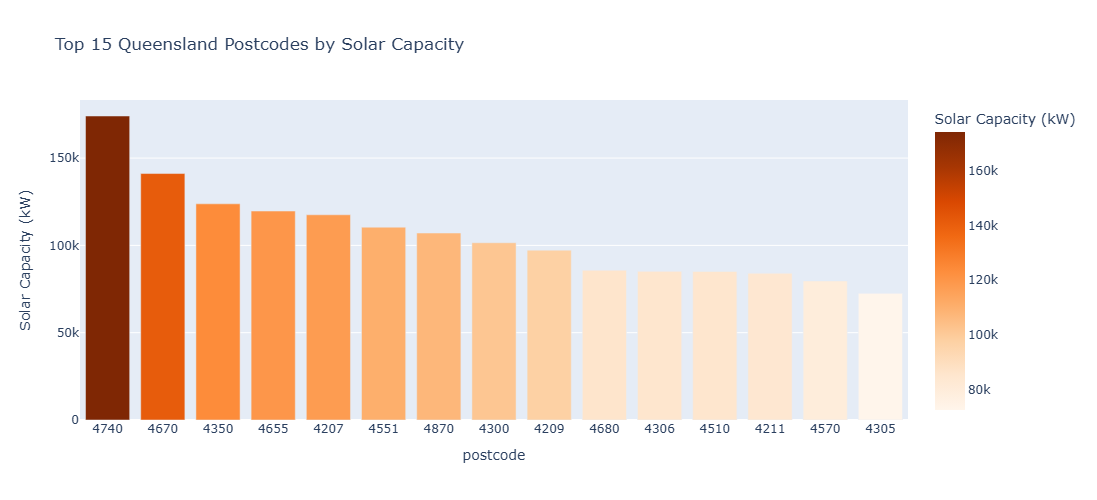

In [19]:
# Bar chart of top postcodes



fig = px.bar(top_postcodes.head(15), 
             x=top_postcodes.head(15).index,
             y='Sum of Solar_capacity_kVA',
             title='Top 15 Queensland Postcodes by Solar Capacity',
             labels={'x': 'postcode', 'Sum of Solar_capacity_kVA': 'Solar Capacity (kW)'},
             color='Sum of Solar_capacity_kVA',
             color_continuous_scale='Oranges')
fig.update_layout(height=500, showlegend=False)
fig.show()

## 9. Business vs Residential Analysis

Understand the split between business and residential DER installations.

In [15]:
# Check if business/residential classification exists

classification_col = "nmi_bus_res2"

print("\nDistribution:")
print(df_qld[classification_col].value_counts())



Distribution:
nmi_bus_res2
RESIDENTIAL    418
BUSINESS       381
UNKNOWN         73
Name: count, dtype: int64


## 10. Data Quality Assessment

Identify any issues or gaps in the Queensland data.

In [16]:
print("Data Quality Check:")
print("=" * 80)

# Check for duplicates
duplicates = df_qld.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check for missing critical fields
critical_missing = df_qld.isnull().sum()
if critical_missing.sum() > 0:
    print("\nMissing values in Queensland data:")
    print(critical_missing[critical_missing > 0])
else:
    print("\n✓ No missing values in Queensland data")

# Check data types
print("\nData types:")
print(df_qld.dtypes)

Data Quality Check:
Duplicate rows: 0

Missing values in Queensland data:
nmi_bus_res2    1
dtype: int64

Data types:
state                                         str
postcode                                      str
nmi_bus_res2                                  str
Sum of Num_DER_Sites                        int64
Sum of Num_DER_Connections                  int64
Sum of Installed_DER_capacity_kVA         float64
Sum of Solar_Connections                    int64
Sum of Solar_Devices                        int64
Sum of Solar_capacity_kVA                 float64
Sum of Battery_Connections                  int64
Sum of Battery_Devices                      int64
Sum of Battery_capacity_kVA               float64
Sum of Battery_Storage_kVAh               float64
Sum of Num_Other_Connections                int64
Sum of Installed_OtherDER_capacity_kVA    float64
dtype: object


## 11. Save Processed Queensland Data

Save the cleaned Queensland subset for future analysis.

In [17]:
# Save Queensland data
qld_output_file = os.path.join(data_processed, 'qld_der_data.csv')
df_qld.to_csv(qld_output_file, index=False)
print(f"✓ Queensland data saved to: {qld_output_file}")
print(f"  Rows saved: {len(df_qld):,}")
print(f"  File size: {os.path.getsize(qld_output_file) / 1024:.1f} KB")

✓ Queensland data saved to: C:\Users\jlope\Documents\Projects\DER-Integration-QLD\data\processed\qld_der_data.csv
  Rows saved: 873
  File size: 67.2 KB


## 12. Key Findings & Next Steps

In [18]:
print("="*80)
print("KEY FINDINGS - Initial Exploration")
print("="*80)
print("\n1. Data Structure:")
print(f"   - Total Queensland postcodes: {df_qld['postcode' if 'postcode' in df_qld.columns else df_qld.columns[0]].nunique() if len(df_qld) > 0 else 'N/A'}")
print(f"   - Data reporting date: December, 2025")
print(f"   - Aggregation level: Postcode")

print("\n2. Data Quality:")
print(" No duplicates, neglectable missing values and 74 unknown classifcations subject to further analysis and discovery")

print("\n" + "="*80)
print("NEXT STEPS")
print("="*80)
print("\n1. Identify exact column names and create summary statistics")
print("2. Create visualizations of DER growth trends and more advanced visual, including maps")
print("3. Analyze geographic clustering patterns")
print("4. Investigate data integration challenges across postcodes")
print("5. Begin protocol/standards analysis for data integration")
print("\n" + "="*80)

KEY FINDINGS - Initial Exploration

1. Data Structure:
   - Total Queensland postcodes: 422
   - Data reporting date: December, 2025
   - Aggregation level: Postcode

2. Data Quality:
 No duplicates, neglectable missing values and 74 unknown classifcations subject to further analysis and discovery

3. Coverage:
  Placeholder for analysis result, pending to create map

NEXT STEPS

1. Identify exact column names and create summary statistics
2. Create visualizations of DER growth trends
3. Analyze geographic clustering patterns
4. Investigate data integration challenges across postcodes
5. Begin protocol/standards analysis for data integration



---

## Notes & Observations

**Document your findings here:**


### Interesting Patterns:
- More adoption by business types than residential
- Mackay and Bundi are the top places adopting DERs

### Questions for Further Investigation:
- What's the correlation between Mackay and Bundi to be on top


### Data Integration Insights:
- What standardization challenges are visible in this aggregated data?
- Installed DER capacity sometimes differ greatly from actual usage, infrastructure exists but lacks adoption?

---


**Last Updated:** February 15, 2026

**Status:** 🚧 Finished - Initial understanding of dataset, columns and QLD filtered dataset extracted